# SASRec v3 — Feature-Aware (Fair Comparison with BERT4Rec v2)

**Fixes over v2:**
- Removed `key_padding_mask` from `nn.MultiheadAttention` — passing both the causal mask
  and key-padding mask simultaneously caused all-masked queries for leading PAD positions,
  producing `NaN` from `softmax([-inf, -inf, ...])`. This silently corrupted weights.
- Added post-attention PAD zeroing (original SASRec style) to prevent PAD tokens
  accumulating representations across layers.
- Added NaN-loss guard in training loop to skip corrupted batches cleanly.

Everything else matches BERT4Rec v2:
- Same datasets (`data2.csv`, `item_features2.csv`, `user_features2.csv`)
- Same leave-one-out split, same token convention (`PAD=0`, items start at `1`)
- Same model capacity (hidden=128, heads=4, layers=2)
- Same training budget (200 epochs, cosine annealing LR, grad clipping)
- Same evaluation: HR@{5,10,20}, NDCG@{5,10,20}, MRR — full ranking over all items
- Same item feature matrix + user feature fusion

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Config

In [ ]:
import os, math, random
from collections import OrderedDict

import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import torch.optim as optim
from torch.nn.functional import cosine_similarity
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive'
    print('Google Drive mounted.')
except Exception:
    DRIVE_ROOT = '.'
    print('Not in Colab — using local directory.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
INTERACTIONS_PATH  = os.path.join(DRIVE_ROOT, 'data2.csv')
ITEM_FEATURES_PATH = os.path.join(DRIVE_ROOT, 'item_features2.csv')
USER_FEATURES_PATH = os.path.join(DRIVE_ROOT, 'user_features2.csv')
MODEL_SAVE_PATH    = './sasrec_v3.pth'

# ── Vocab ─────────────────────────────────────────────────────────────────────
# SASRec: PAD=0, real items start at 1  (no MASK token needed)
vocab_config = {'padding_index': 0}

# ── Training ──────────────────────────────────────────────────────────────────
train_config = {
    'batch_size':       256,
    'num_epochs':       200,
    'lr':               1e-3,
    'lr_resume':        1e-4,
    'optimizer_betas':  (0.9, 0.999),
    'weight_decay':     0.01,
    'grad_clip':        1.0,
    'patience':         20,
    'additional_epochs': 40,
}

# ── Model ─────────────────────────────────────────────────────────────────────
model_config = {
    'hidden_dims':             128,
    'num_attention_heads':     4,
    'num_hidden_layers':       2,
    'intermediate_dims':       512,
    'max_seq_len':             50,
    'vocab_size':              0,     # filled after loading data
    'user_feature_dim':        0,     # filled after loading user features
    'hidden_dropout_prob':     0.1,
    'attention_dropout_prob':  0.1,
    'classifier_dropout_prob': 0.1,
    'initializer_range':       0.02,
    'eps':                     1e-12,
}

notebook_config = {
    'model_train_flg':        True,
    'model_train_resume_flg': False,
    'model_save_path':        MODEL_SAVE_PATH,
    'model_load_path':        MODEL_SAVE_PATH,
}

print('Config ready.')

Config ready.


## 2. Data Loading & Preprocessing

In [ ]:
# ── Item features ─────────────────────────────────────────────────────────────
item_features_pd = (
    pd.read_csv(ITEM_FEATURES_PATH)
      .sort_values('item_idx')
      .reset_index(drop=True)
)
item_lookup_df = item_features_pd[['item_idx', 'item_id']].set_index('item_idx')
num_items = len(item_features_pd)

# SASRec token shift: PAD=0, item_idx → token = item_idx + 1
model_config['vocab_size'] = num_items + 1
print(f'Items: {num_items:,}  |  vocab_size: {model_config["vocab_size"]}')

Items: 8,411  |  vocab_size: 8412


In [ ]:
def build_item_feature_matrix(df: pd.DataFrame):
    """
    Same as BERT4Rec v2 but padded array is (num_items+1, d):
      row 0   = PAD sentinel (zeros)
      rows 1+ = real items (item_idx + 1)
    """
    ignore = {'item_idx', 'item_id', 'title', 'genres_raw', 'release_date_raw'}
    num_cols = [
        c for c in df.columns
        if c not in ignore | {'original_language'}
        and pd.api.types.is_numeric_dtype(df[c])
    ]
    lang_dummies = pd.get_dummies(
        df['original_language'].fillna('unknown').astype(str), prefix='lang'
    )
    feature_df = pd.concat([df[num_cols].fillna(0), lang_dummies], axis=1).fillna(0)

    binary_cols = {c for c in feature_df.columns if feature_df[c].nunique() <= 2}
    scale_cols  = [c for c in feature_df.columns if c not in binary_cols]
    if scale_cols:
        feature_df[scale_cols] = StandardScaler().fit_transform(feature_df[scale_cols])

    arr = feature_df.to_numpy(dtype=np.float32)
    # row 0 = PAD zeros; rows 1..N = real items
    padded = np.zeros((len(df) + 1, arr.shape[1]), dtype=np.float32)
    padded[1:] = arr
    return torch.tensor(padded, dtype=torch.float32), feature_df.columns.tolist()


item_feature_tensor, item_feature_columns = build_item_feature_matrix(item_features_pd)
print(f'Item feature matrix: {item_feature_tensor.shape}')

Item feature matrix: torch.Size([8412, 78])


In [ ]:
def build_user_feature_matrix(df: pd.DataFrame, sparsity_threshold: float = 0.95):
    """
    Identical to BERT4Rec v2: drop near-zero sparse columns,
    one-hot ordinal cols, StandardScale continuous cols.
    """
    drop_meta = {'user_idx', 'user_id', 'first_seen', 'last_seen'}
    ordinal   = {'user_engagement_tier', 'user_preferred_hour_bucket'}

    numeric_df = df.drop(columns=[c for c in drop_meta if c in df.columns], errors='ignore')
    num_only   = numeric_df.select_dtypes(include='number')
    zero_frac  = (num_only == 0).mean()
    sparse_cols = zero_frac[zero_frac >= sparsity_threshold].index.tolist()
    print(f'  Dropping {len(sparse_cols)} sparse columns (>= {sparsity_threshold*100:.0f}% zeros)')

    keep_num = [c for c in num_only.columns if c not in sparse_cols and c not in ordinal]
    parts = []
    if keep_num:
        sub = numeric_df[keep_num].fillna(0).copy()
        cont = [c for c in keep_num if sub[c].nunique() > 2]
        if cont:
            sub[cont] = StandardScaler().fit_transform(sub[cont])
        parts.append(sub)

    for col in ordinal:
        if col in df.columns:
            parts.append(pd.get_dummies(df[col].fillna(0).astype(int), prefix=col))

    feature_df = pd.concat(parts, axis=1).fillna(0)
    arr = feature_df.to_numpy(dtype=np.float32)
    print(f'  User feature matrix: {arr.shape[0]:,} x {arr.shape[1]}')
    return torch.tensor(arr, dtype=torch.float32), feature_df.columns.tolist()


user_features_pd = (
    pd.read_csv(USER_FEATURES_PATH)
      .sort_values('user_idx')
      .reset_index(drop=True)
)
user_feature_tensor, user_feature_columns = build_user_feature_matrix(user_features_pd)
model_config['user_feature_dim'] = user_feature_tensor.shape[1]
print(f'  user_feature_dim: {model_config["user_feature_dim"]}')

  Dropping 9 sparse columns (>= 95% zeros)
  User feature matrix: 161,619 x 38
  user_feature_dim: 38


In [ ]:
# ── Interactions ──────────────────────────────────────────────────────────────
df = pl.read_csv(INTERACTIONS_PATH)
df = df.with_columns([
    pl.col('datetime').str.to_datetime(format='%Y-%m-%d %H:%M:%S', strict=False),
    # SASRec token shift: +1 (PAD=0, items start at 1)
    (pl.col('item_idx') + 1).alias('item_token'),
])
print(f'Interactions: {len(df):,}  |  Users: {df["user_id"].n_unique():,}')

# Sanity check
assert int(df['item_token'].max()) < model_config['vocab_size'], 'Token exceeds vocab!'

# ── Build sequences ───────────────────────────────────────────────────────────
user_rows = (
    df.group_by(['user_id', 'user_idx'])
      .agg(pl.col('item_token').sort_by(pl.col('datetime')).alias('sequence'))
      .sort('user_idx')
)
sequences    = user_rows['sequence'].to_list()
user_indices = user_rows['user_idx'].to_list()

# ── Leave-one-out split ───────────────────────────────────────────────────────
train_seqs, val_data, test_data = [], [], []
train_user_idx, val_user_idx, test_user_idx = [], [], []

for seq, uidx in zip(sequences, user_indices):
    if len(seq) < 3:
        continue
    train_seqs.append(seq[:-2]);  train_user_idx.append(uidx)
    val_data.append((seq[:-2], seq[-2]));   val_user_idx.append(uidx)
    test_data.append((seq[:-1], seq[-1]));  test_user_idx.append(uidx)

print(f'Train: {len(train_seqs):,}  |  Val: {len(val_data):,}  |  Test: {len(test_data):,}')

Interactions: 649,250  |  Users: 161,619
Train: 72,138  |  Val: 72,138  |  Test: 72,138


In [ ]:
# ── Popularity-debiased loss weights ──────────────────────────────────────────
item_counts  = df['item_token'].value_counts().to_pandas().set_index('item_token')['count']
weight_vec   = np.ones(model_config['vocab_size'], dtype=np.float32)
for tok, cnt in item_counts.items():
    weight_vec[int(tok)] = 1.0 / (cnt ** 0.5)
weight_vec[0] = 0.0   # PAD
item_loss_weights = torch.tensor(weight_vec, dtype=torch.float32)
print(f'Loss weights built. Non-zero: {(item_loss_weights > 0).sum().item():,}')

Loss weights built. Non-zero: 8,411


## 3. Model Definition

### 3.1 Embedding

In [ ]:
class SASRecEmbedding(nn.Module):
    """
    Item embedding + item-feature projection (gated) + position embedding.
    Identical feature fusion to BERT4Rec v2.
    """
    def __init__(self, cfg, vcfg, item_feature_matrix):
        super().__init__()
        H, r = cfg['hidden_dims'], cfg['initializer_range']

        self.item_embedding     = nn.Embedding(cfg['vocab_size'], H,
                                               padding_idx=vcfg['padding_index'])
        self.position_embedding = nn.Embedding(cfg['max_seq_len'], H)
        self.feature_projection = nn.Linear(item_feature_matrix.shape[1], H, bias=False)

        # Small initial gate so features don't overpower item IDs early on
        self.fusion_gate = nn.Parameter(torch.tensor(-2.0))
        self.register_buffer('item_feature_matrix', item_feature_matrix)

        self.layer_norm = nn.LayerNorm(H, eps=cfg['eps'])
        self.dropout    = nn.Dropout(cfg['hidden_dropout_prob'])

        init.normal_(self.item_embedding.weight, std=r)
        init.normal_(self.position_embedding.weight, std=r)
        init.normal_(self.feature_projection.weight, std=r)

    def forward(self, input_ids):
        B, L = input_ids.shape
        pos   = torch.arange(L, device=input_ids.device).unsqueeze(0)
        id_e  = self.item_embedding(input_ids)
        pos_e = self.position_embedding(pos)
        feat_e = self.feature_projection(self.item_feature_matrix[input_ids])
        gate   = torch.sigmoid(self.fusion_gate)
        x = id_e + gate * feat_e + pos_e
        return self.dropout(self.layer_norm(x))

### 3.2 User encoder

In [ ]:
class UserEncoder(nn.Module):
    """
    Same gated MLP as BERT4Rec v2 — projects sparse user features to hidden dim.
    Output is broadcast-added to every sequence position.
    """
    def __init__(self, user_feat_dim: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.fc1  = nn.Linear(user_feat_dim, hidden_dim)
        self.fc2  = nn.Linear(hidden_dim, hidden_dim)
        self.gate = nn.Linear(user_feat_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)
        self.drop = nn.Dropout(dropout)
        for m in [self.fc1, self.fc2, self.gate]:
            init.xavier_uniform_(m.weight); init.zeros_(m.bias)

    def forward(self, user_feats):
        g = torch.sigmoid(self.gate(user_feats))
        h = self.drop(F.gelu(self.fc1(user_feats)))
        h = self.drop(self.fc2(h)) * g
        return self.norm(h).unsqueeze(1)   # (B, 1, H)

### 3.3 Transformer layer (causal)

**Fix vs v2:** `key_padding_mask` is no longer passed to `nn.MultiheadAttention`.

In v2, combining the causal mask with `key_padding_mask` caused every leading PAD
position to have **all keys masked** (causal mask blocked future positions; padding mask
blocked past PAD positions). `softmax([-inf, -inf, ...])` produces `NaN`, which
propagated through the loss and corrupted model weights silently.

The fix is consistent with the original SASRec paper: PAD tokens have zero item
embeddings (`padding_idx=0`) so they carry no semantic content, and their loss
contributions are suppressed via `ignore_index=-100`. After each attention block
we explicitly zero PAD positions to prevent them accumulating representations.

In [ ]:
class SASRecLayer(nn.Module):
    """
    Pre-LN transformer with causal attention only.

    key_padding_mask is intentionally NOT passed to MultiheadAttention.
    Passing both the causal mask and key_padding_mask causes all-masked
    queries for leading PAD positions (NaN from softmax). Instead, PAD
    positions are zeroed out after attention via an explicit mask.
    """
    def __init__(self, cfg):
        super().__init__()
        H, I, r = cfg['hidden_dims'], cfg['intermediate_dims'], cfg['initializer_range']

        self.attn_norm = nn.LayerNorm(H, eps=cfg['eps'])
        self.attn = nn.MultiheadAttention(
            embed_dim=H,
            num_heads=cfg['num_attention_heads'],
            dropout=cfg['attention_dropout_prob'],
            batch_first=True,
        )
        self.attn_drop = nn.Dropout(cfg['hidden_dropout_prob'])

        self.ffn_norm = nn.LayerNorm(H, eps=cfg['eps'])
        self.fc1 = nn.Linear(H, I)
        self.fc2 = nn.Linear(I, H)
        self.ffn_drop = nn.Dropout(cfg['hidden_dropout_prob'])

        for w in [self.fc1.weight, self.fc2.weight]:
            init.normal_(w, std=r)
        for b in [self.fc1.bias, self.fc2.bias]:
            init.zeros_(b)

    def forward(self, x, causal_mask, pad_mask=None):
        """
        x           : (B, L, H)
        causal_mask : (L, L) bool — True = block (upper-triangular)
        pad_mask    : (B, L) bool — True = PAD position (used for zeroing, not attention masking)
        """
        # Pre-LN attention — causal mask only, no key_padding_mask
        h = self.attn_norm(x)
        h, _ = self.attn(h, h, h,
                         attn_mask=causal_mask,
                         need_weights=False)
        x = x + self.attn_drop(h)

        # Zero out PAD positions so they don't accumulate representations
        # across layers (original SASRec style).
        if pad_mask is not None:
            x = x.masked_fill(pad_mask.unsqueeze(-1), 0.0)

        # Pre-LN FFN
        h = self.ffn_norm(x)
        h = self.fc2(F.gelu(self.fc1(h)))
        x = x + self.ffn_drop(h)

        # Zero out PAD positions again after FFN
        if pad_mask is not None:
            x = x.masked_fill(pad_mask.unsqueeze(-1), 0.0)

        return x

### 3.4 Full SASRec model

In [ ]:
class SASRecV3(nn.Module):
    """
    SASRec with:
      - Item embedding + gated item-feature projection + position embedding
      - User feature fusion (broadcast across sequence positions)
      - Causal transformer encoder (no key_padding_mask in attention — see SASRecLayer)
      - Weight-tied output projection (output weight = item embedding weight)
    """
    def __init__(self, cfg, vcfg, item_feature_matrix, user_feature_dim):
        super().__init__()
        H = cfg['hidden_dims']

        self.embedding    = SASRecEmbedding(cfg, vcfg, item_feature_matrix)
        self.user_encoder = UserEncoder(user_feature_dim, H,
                                        dropout=cfg['hidden_dropout_prob'])
        self.layers       = nn.ModuleList([SASRecLayer(cfg)
                                           for _ in range(cfg['num_hidden_layers'])])
        self.out_norm     = nn.LayerNorm(H, eps=cfg['eps'])

        # Weight tying: output projection shares weights with item embedding
        self.out_proj = nn.Linear(H, cfg['vocab_size'], bias=False)
        self.out_proj.weight = self.embedding.item_embedding.weight

    def _causal_mask(self, L, device):
        """Upper-triangular True mask — positions cannot attend to future tokens."""
        return torch.triu(torch.ones(L, L, device=device, dtype=torch.bool), diagonal=1)

    def forward(self, input_ids, pad_mask=None, user_feats=None):
        x           = self.embedding(input_ids)
        causal_mask = self._causal_mask(input_ids.size(1), input_ids.device)

        if user_feats is not None:
            x = x + self.user_encoder(user_feats)   # broadcast over seq

        for layer in self.layers:
            # pad_mask passed for post-attention zeroing only (not attention masking)
            x = layer(x, causal_mask=causal_mask, pad_mask=pad_mask)

        x      = self.out_norm(x)
        logits = self.out_proj(x)   # (B, L, V)
        return logits


# ── Quick shape check ─────────────────────────────────────────────────────────
_B = 4
_ids  = torch.randint(1, model_config['vocab_size'], (_B, model_config['max_seq_len']))
_ids[:, :5] = 0
_uf   = torch.randn(_B, model_config['user_feature_dim'])
_net  = SASRecV3(model_config, vocab_config, item_feature_tensor,
                  model_config['user_feature_dim'])
_pad  = _ids.eq(0)
_out  = _net(_ids, _pad, _uf)
assert _out.shape == (_B, model_config['max_seq_len'], model_config['vocab_size'])
assert not torch.isnan(_out).any(), 'NaN in forward pass — check model!'
print(f'Model forward pass OK. Output shape: {tuple(_out.shape)}')
total_params = sum(p.numel() for p in _net.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
del _net, _out

Model forward pass OK. Output shape: (4, 50, 8412)
Trainable parameters: 1,516,929


## 4. Dataset & DataLoader

In [ ]:
class SASRecDataset(Dataset):
    """
    SASRec next-item prediction at every position:
      input  = seq[:-1]  (shifted left by 1)
      target = seq[1:]   (the next item at every position)

    This trains the model on all L-1 positions per sequence, giving
    far more signal per sequence than BERT4Rec's ~20% masked positions.
    """
    def __init__(self, sequences, user_indices, user_feature_tensor,
                 max_len, pad_id=0):
        self.sequences           = sequences
        self.user_indices        = user_indices
        self.user_feature_tensor = user_feature_tensor
        self.max_len = max_len
        self.pad_id  = pad_id

    def __len__(self): return len(self.sequences)

    def __getitem__(self, idx):
        seq  = list(self.sequences[idx])
        uidx = self.user_indices[idx]

        inp    = seq[:-1]
        target = seq[1:]

        # Truncate to max_len
        inp    = inp[-self.max_len:]
        target = target[-self.max_len:]

        # Left-pad
        pad_n  = self.max_len - len(inp)
        inp    = [self.pad_id] * pad_n + inp
        target = [-100]        * pad_n + target   # -100 ignored by cross_entropy

        inp_t    = torch.tensor(inp,    dtype=torch.long)
        target_t = torch.tensor(target, dtype=torch.long)
        pad_mask = inp_t.eq(self.pad_id)
        user_feat = self.user_feature_tensor[uidx]

        return inp_t, target_t, pad_mask, user_feat


train_loader = DataLoader(
    SASRecDataset(train_seqs, train_user_idx, user_feature_tensor,
                  model_config['max_seq_len'], pad_id=vocab_config['padding_index']),
    batch_size=train_config['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
print(f'Train loader ready. {len(train_loader)} batches/epoch.')

Train loader ready. 282 batches/epoch.


## 5. Training

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = SASRecV3(
    model_config, vocab_config,
    item_feature_tensor,
    model_config['user_feature_dim'],
).to(device)

item_loss_weights = item_loss_weights.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

optimizer = optim.AdamW(
    model.parameters(),
    lr=train_config['lr'],
    betas=train_config['optimizer_betas'],
    weight_decay=train_config['weight_decay'],
)

# Cosine annealing with warm restarts
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=50, T_mult=1, eta_min=1e-5
)

start_epoch        = 0
batch_loss_history = []
epoch_loss_history = []
best_val_hr        = -1.0
bad_epochs         = 0

Device: cuda
Trainable parameters: 1,516,929


In [ ]:
# ── Inference helper ──────────────────────────────────────────────────────────
def prepare_inference_input(history, user_feat, cfg, vcfg, device):
    """
    For SASRec inference we feed the full history (no MASK appended).
    The prediction for the next item comes from the hidden state at
    the LAST real token position.
    """
    max_len = cfg['max_seq_len']
    pad_id  = vcfg['padding_index']

    seq   = list(history)[-max_len:]
    pad_n = max_len - len(seq)
    padded   = [pad_id] * pad_n + seq
    pad_mask = [True]   * pad_n + [False] * len(seq)

    ids_t  = torch.tensor(padded,   dtype=torch.long).unsqueeze(0).to(device)
    mask_t = torch.tensor(pad_mask, dtype=torch.bool).unsqueeze(0).to(device)
    uf_t   = user_feat.unsqueeze(0).to(device)
    return ids_t, mask_t, uf_t

Training for 200 epochs.
  Epoch 1/200 | Batch 0/282 | Loss 8.7921 | LR 1.00e-03
  Epoch 1/200 | Batch 100/282 | Loss 7.8446 | LR 1.00e-03
  Epoch 1/200 | Batch 200/282 | Loss 7.2624 | LR 1.00e-03
Epoch 1 done. Avg loss: 7.5578  (NaN batches skipped total: 0)
  Epoch 2/200 | Batch 0/282 | Loss 6.3803 | LR 9.99e-04
  Epoch 2/200 | Batch 100/282 | Loss 6.0831 | LR 9.99e-04
  Epoch 2/200 | Batch 200/282 | Loss 5.7234 | LR 9.99e-04
Epoch 2 done. Avg loss: 5.9804  (NaN batches skipped total: 0)
  Epoch 3/200 | Batch 0/282 | Loss 5.3560 | LR 9.96e-04
  Epoch 3/200 | Batch 100/282 | Loss 5.1124 | LR 9.96e-04
  Epoch 3/200 | Batch 200/282 | Loss 5.2003 | LR 9.96e-04
Epoch 3 done. Avg loss: 5.2120  (NaN batches skipped total: 0)
  Epoch 4/200 | Batch 0/282 | Loss 4.8795 | LR 9.91e-04
  Epoch 4/200 | Batch 100/282 | Loss 4.5844 | LR 9.91e-04
  Epoch 4/200 | Batch 200/282 | Loss 4.9181 | LR 9.91e-04
Epoch 4 done. Avg loss: 4.7533  (NaN batches skipped total: 0)
  Epoch 5/200 | Batch 0/282 | Loss 

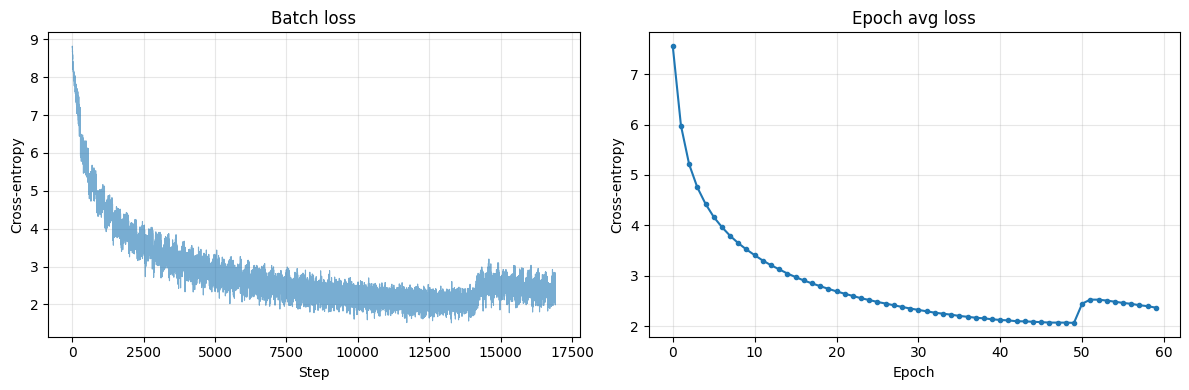

Loss curves saved.


In [ ]:
if notebook_config['model_train_flg']:
    if notebook_config['model_train_resume_flg'] and os.path.exists(notebook_config['model_load_path']):
        ckpt = torch.load(notebook_config['model_load_path'], map_location=device)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        for state in optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor): state[k] = v.to(device)
        start_epoch = ckpt['epoch'] + 1
        num_epochs  = start_epoch + train_config['additional_epochs']
        for g in optimizer.param_groups: g['lr'] = train_config['lr_resume']
        print(f'Resuming from epoch {start_epoch}')
    else:
        num_epochs = train_config['num_epochs']
        print(f'Training for {num_epochs} epochs.')

    nan_batches_skipped = 0

    for epoch in range(start_epoch, num_epochs):
        model.train()
        epoch_loss   = 0.0
        valid_batches = 0

        for i, (inp_b, lbl_b, pad_b, usr_b) in enumerate(train_loader):
            inp_b = inp_b.to(device)
            lbl_b = lbl_b.to(device)
            pad_b = pad_b.to(device)
            usr_b = usr_b.to(device)

            logits = model(inp_b, pad_b, usr_b)   # (B, L, V)

            loss = F.cross_entropy(
                logits.reshape(-1, model_config['vocab_size']),
                lbl_b.reshape(-1),
                ignore_index=-100,
                weight=item_loss_weights,
            )

            # Guard: skip batch if loss is NaN/Inf (should not happen with the
            # v3 attention fix, but kept as a safety net).
            if not torch.isfinite(loss):
                nan_batches_skipped += 1
                optimizer.zero_grad()
                continue

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), train_config['grad_clip'])
            optimizer.step()

            batch_loss_history.append(loss.item())
            epoch_loss += loss.item()
            valid_batches += 1

            if i % 100 == 0:
                print(f'  Epoch {epoch+1}/{num_epochs} | Batch {i}/{len(train_loader)} '
                      f'| Loss {loss.item():.4f} | LR {scheduler.get_last_lr()[0]:.2e}')

        scheduler.step()
        avg = epoch_loss / max(valid_batches, 1)
        epoch_loss_history.append(avg)
        print(f'Epoch {epoch+1} done. Avg loss: {avg:.4f}  '
              f'(NaN batches skipped total: {nan_batches_skipped})')

        # ── Save checkpoint ───────────────────────────────────────────────────
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss':                 avg,
        }, notebook_config['model_save_path'])

        # ── Early stopping on val HR@10 ───────────────────────────────────────
        # Only check every 5 epochs to avoid stopping during LR restart dips
        if (epoch + 1) % 5 == 0:
            model.eval()
            quick_hits = []
            with torch.no_grad():
                for (hist, tgt), uidx in zip(val_data[:500], val_user_idx[:500]):
                    uf = user_feature_tensor[uidx]
                    ids_t, mask_t, uf_t = prepare_inference_input(
                        hist, uf, model_config, vocab_config, device)
                    logits = model(ids_t, mask_t, uf_t)
                    scores = logits[0, -1].clone()
                    scores[vocab_config['padding_index']] = -1e9
                    for item in hist: scores[item] = -1e9
                    ranked = torch.argsort(scores, descending=True).tolist()
                    quick_hits.append(1.0 if tgt in ranked[:10] else 0.0)
            quick_hr = float(np.mean(quick_hits))
            print(f'  Quick Val HR@10 (500 users): {quick_hr:.4f}')
            if quick_hr > best_val_hr:
                best_val_hr = quick_hr
                bad_epochs  = 0
            else:
                bad_epochs += 1
                if bad_epochs >= train_config['patience'] // 5:
                    print('Early stopping triggered.')
                    break

    # ── Loss curves ───────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(batch_loss_history, alpha=0.6, linewidth=0.8)
    ax1.set(title='Batch loss', xlabel='Step', ylabel='Cross-entropy')
    ax1.grid(True, alpha=0.3)
    ax2.plot(epoch_loss_history, marker='o', markersize=3)
    ax2.set(title='Epoch avg loss', xlabel='Epoch', ylabel='Cross-entropy')
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('sasrec_training_loss.png', dpi=120)
    plt.show()
    print('Loss curves saved.')

else:
    ckpt = torch.load(notebook_config['model_load_path'], map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print('Pre-trained model loaded.')

## 6. Evaluation — HR@K, NDCG@K, MRR

In [ ]:
def evaluate_all(model, eval_data, user_indices, user_feature_tensor,
                 cfg, vcfg, device, k_list=(5, 10, 20)):
    """
    Single-pass evaluation over all users.
    Returns HR@K, NDCG@K for each K, plus MRR (full ranking).
    Identical protocol to BERT4Rec v2 for a fair comparison.
    """
    model.eval()
    hits  = {k: [] for k in k_list}
    ndcgs = {k: [] for k in k_list}
    rr    = []

    with torch.no_grad():
        for (history, target), uidx in zip(eval_data, user_indices):
            user_feat = user_feature_tensor[uidx]
            ids_t, mask_t, uf_t = prepare_inference_input(
                history, user_feat, cfg, vcfg, device)

            # SASRec: score at the LAST non-pad position
            logits = model(ids_t, mask_t, uf_t)
            scores = logits[0, -1].clone()

            # Suppress PAD and already-seen items
            scores[vcfg['padding_index']] = -1e9
            for item in history:
                scores[item] = -1e9

            ranked = torch.argsort(scores, descending=True).tolist()

            # MRR
            if target in ranked:
                rr.append(1.0 / (ranked.index(target) + 1))
            else:
                rr.append(0.0)

            # HR + NDCG at each K
            for k in k_list:
                if target in ranked[:k]:
                    rank = ranked.index(target) + 1
                    hits[k].append(1.0)
                    ndcgs[k].append(1.0 / math.log2(rank + 1))
                else:
                    hits[k].append(0.0)
                    ndcgs[k].append(0.0)

    results = {
        k: {f'HR@{k}':   round(float(np.mean(hits[k])),  4),
            f'NDCG@{k}': round(float(np.mean(ndcgs[k])), 4)}
        for k in k_list
    }
    results['MRR'] = {'MRR': round(float(np.mean(rr)), 4)}
    return results

In [ ]:
print('=== Validation ===')
val_metrics = evaluate_all(model, val_data, val_user_idx, user_feature_tensor,
                            model_config, vocab_config, device)
for k, m in val_metrics.items():
    print(f'  {m}')

print()
print('=== Test ===')
test_metrics = evaluate_all(model, test_data, test_user_idx, user_feature_tensor,
                             model_config, vocab_config, device)
for k, m in test_metrics.items():
    print(f'  {m}')

=== Validation ===
  {'HR@5': 0.2407, 'NDCG@5': 0.1798}
  {'HR@10': 0.3038, 'NDCG@10': 0.2002}
  {'HR@20': 0.3719, 'NDCG@20': 0.2174}
  {'MRR': 0.1771}

=== Test ===
  {'HR@5': 0.2212, 'NDCG@5': 0.1647}
  {'HR@10': 0.2849, 'NDCG@10': 0.1853}
  {'HR@20': 0.3497, 'NDCG@20': 0.2016}
  {'MRR': 0.1634}


In [ ]:
print()
print('BERT4Rec v2 baseline (for reference):')
print('  HR@10=0.3085  NDCG@10=0.2081  HR@20=0.3720  MRR=0.1966')
print()
print('SASRec v3 results:')
for k in [5, 10, 20]:
    m = test_metrics[k]
    print(f'  {m}')
print(f'  {test_metrics["MRR"]}')


BERT4Rec v2 baseline (for reference):
  HR@10=0.3085  NDCG@10=0.2081  HR@20=0.3720  MRR=0.1966

SASRec v3 results:
  {'HR@5': 0.2212, 'NDCG@5': 0.1647}
  {'HR@10': 0.2849, 'NDCG@10': 0.1853}
  {'HR@20': 0.3497, 'NDCG@20': 0.2016}
  {'MRR': 0.1634}


## 7. Inference & Recommendation Demo

In [ ]:
def get_item_name(token_id, item_lookup_df, vcfg):
    if token_id == vcfg['padding_index']: return '<PAD>'
    item_idx = int(token_id) - 1   # SASRec shift: token = item_idx + 1
    return (
        item_lookup_df.loc[item_idx, 'item_id']
        if item_idx in item_lookup_df.index else f'unk_{token_id}'
    )


def recommend(history, user_idx, model, item_lookup_df, user_feature_tensor,
              vcfg, cfg, device, k=10):
    model.eval()
    user_feat = user_feature_tensor[user_idx]
    ids_t, mask_t, uf_t = prepare_inference_input(history, user_feat, cfg, vcfg, device)

    with torch.no_grad():
        logits = model(ids_t, mask_t, uf_t)

    scores = logits[0, -1].clone()
    scores[vcfg['padding_index']] = -1e9
    for item in history:
        scores[item] = -1e9

    probs   = torch.softmax(scores, dim=0)
    top_v, top_i = torch.topk(probs, k=k)

    topk = OrderedDict(
        (get_item_name(i.item(), item_lookup_df, vcfg), round(p.item(), 6))
        for i, p in zip(top_i, top_v)
    )
    sampled_i = torch.multinomial(probs, num_samples=k, replacement=False)
    sampled   = OrderedDict(
        (get_item_name(i.item(), item_lookup_df, vcfg), round(probs[i].item(), 6))
        for i in sampled_i
    )
    return {'topk': topk, 'sampled': sampled}

In [ ]:
sample_history, sample_target = val_data[0]
sample_uidx = val_user_idx[0]

print(f'User idx       : {sample_uidx}')
print(f'History length : {len(sample_history)} items')
print(f'True next item : {get_item_name(sample_target, item_lookup_df, vocab_config)}')

results = recommend(sample_history, sample_uidx, model, item_lookup_df,
                    user_feature_tensor, vocab_config, model_config, device)

print('\nTop-10 (deterministic):')
true_name = get_item_name(sample_target, item_lookup_df, vocab_config)
for name, p in results['topk'].items():
    marker = '  <- TRUE' if name == true_name else ''
    print(f'  {name:<30}  p={p:.6f}{marker}')

print('\nTop-10 (sampled):')
for name, p in results['sampled'].items():
    print(f'  {name:<30}  p={p:.6f}')

User idx       : 1
History length : 22 items
True next item : d601124c11

Top-10 (deterministic):
  bad0e2356a                      p=0.256449
  a8df8dd2f3                      p=0.105653
  13e9f8fac8                      p=0.101803
  7f843247be                      p=0.057697
  c3e61fc9b9                      p=0.049859
  0fc283bc6d                      p=0.041780
  3a811557f5                      p=0.020455
  13de65e022                      p=0.019666
  881e4cdac3                      p=0.017254
  ea0289c40c                      p=0.016885

Top-10 (sampled):
  bad0e2356a                      p=0.256449
  a8df8dd2f3                      p=0.105653
  7f843247be                      p=0.057697
  c3e61fc9b9                      p=0.049859
  e3280e2491                      p=0.002855
  5a76510961                      p=0.007235
  ea0289c40c                      p=0.016885
  3a811557f5                      p=0.020455
  f91954e1ed                      p=0.000011
  0700b5dbdb                

## 8. Item-Embedding Similarity

In [ ]:
def get_similar_items(query_token, model, item_lookup_df, vcfg, k=10):
    """
    Uses item embedding + feature projection for similarity,
    same as BERT4Rec v2.
    """
    with torch.no_grad():
        base = model.embedding.item_embedding.weight.detach().cpu()
        feat = model.embedding.feature_projection(
                   model.embedding.item_feature_matrix).detach().cpu()
        combined = base + feat   # (V, H)

    q    = combined[query_token]
    sims = cosine_similarity(q.unsqueeze(0), combined[1:], dim=1)  # skip PAD row
    top_sims, top_idx = torch.topk(sims, k + 1)

    results = []
    for idx, score in zip(top_idx.tolist(), top_sims.tolist()):
        tok = idx + 1   # +1 because we skipped row 0 (PAD)
        if tok == query_token: continue
        results.append((get_item_name(tok, item_lookup_df, vcfg), round(score, 4)))
        if len(results) == k: break

    return {
        'query':   get_item_name(query_token, item_lookup_df, vcfg),
        'similar': results,
    }


query_tok   = val_data[0][0][0]
sim_results = get_similar_items(query_tok, model, item_lookup_df, vocab_config)
print(f'Similar to: {sim_results["query"]}')
for name, score in sim_results['similar']:
    print(f'  {name:<30}  cos_sim={score:.4f}')

print('\nSASRec v3 pipeline complete.')

Similar to: 7314699c23
  d2b25e1c92                      cos_sim=0.7692
  00d10b4913                      cos_sim=0.7520
  f8265fd126                      cos_sim=0.7345
  3343c521af                      cos_sim=0.7235
  a2d929e113                      cos_sim=0.7228
  ebb5681d87                      cos_sim=0.7108
  7a3417b9ef                      cos_sim=0.7094
  9b2f73f9e9                      cos_sim=0.7073
  0047acb471                      cos_sim=0.7053
  9d046162e5                      cos_sim=0.7052

SASRec v3 pipeline complete.
